# ST1504 CA2 Part A: Final Model Comparison and Enhancement

## Objective

This notebook consolidates the final decision for CIFAR-10 image generation. It first compares the group's finalised Variational Autoencoder (VAE) with the improved unconditional DCGAN before augmentation. The selected DCGAN is then restored from saved weights and fine-tuned using mild horizontal-flip augmentation.

The full development and training histories remain in `Ptajh.ipynb` and `PtAKayden.ipynb`. They are not repeated here because the purpose of this notebook is final model selection and enhancement, not retraining every earlier experiment.


## 1. Final VAE and Improved DCGAN Comparison

### Evaluation approach

Both models were assessed using 100 images sampled from their latent spaces rather than reconstructions of test images. Each image was placed into one of three categories:

- **Clear:** A recognisable object with a reasonably coherent structure.
- **Marginal:** A plausible object or silhouette, but with ambiguous or blurry details.
- **Nonsense:** No recognisable object or meaningful structure.

The **plausible acceptance rate** is calculated as `clear + marginal`. The comparison uses the partner's recorded VAE assessment and the index-documented DCGAN assessment. FID is shown only as supporting information because the VAE FID run ended with a GPU memory error; therefore, FID is not used to rank the two model families.


### Finalised VAE — 100 Randomly Generated Images

The VAE output below was produced by decoding 100 random latent vectors. Its sigmoid output is displayed in the range `[0, 1]`.

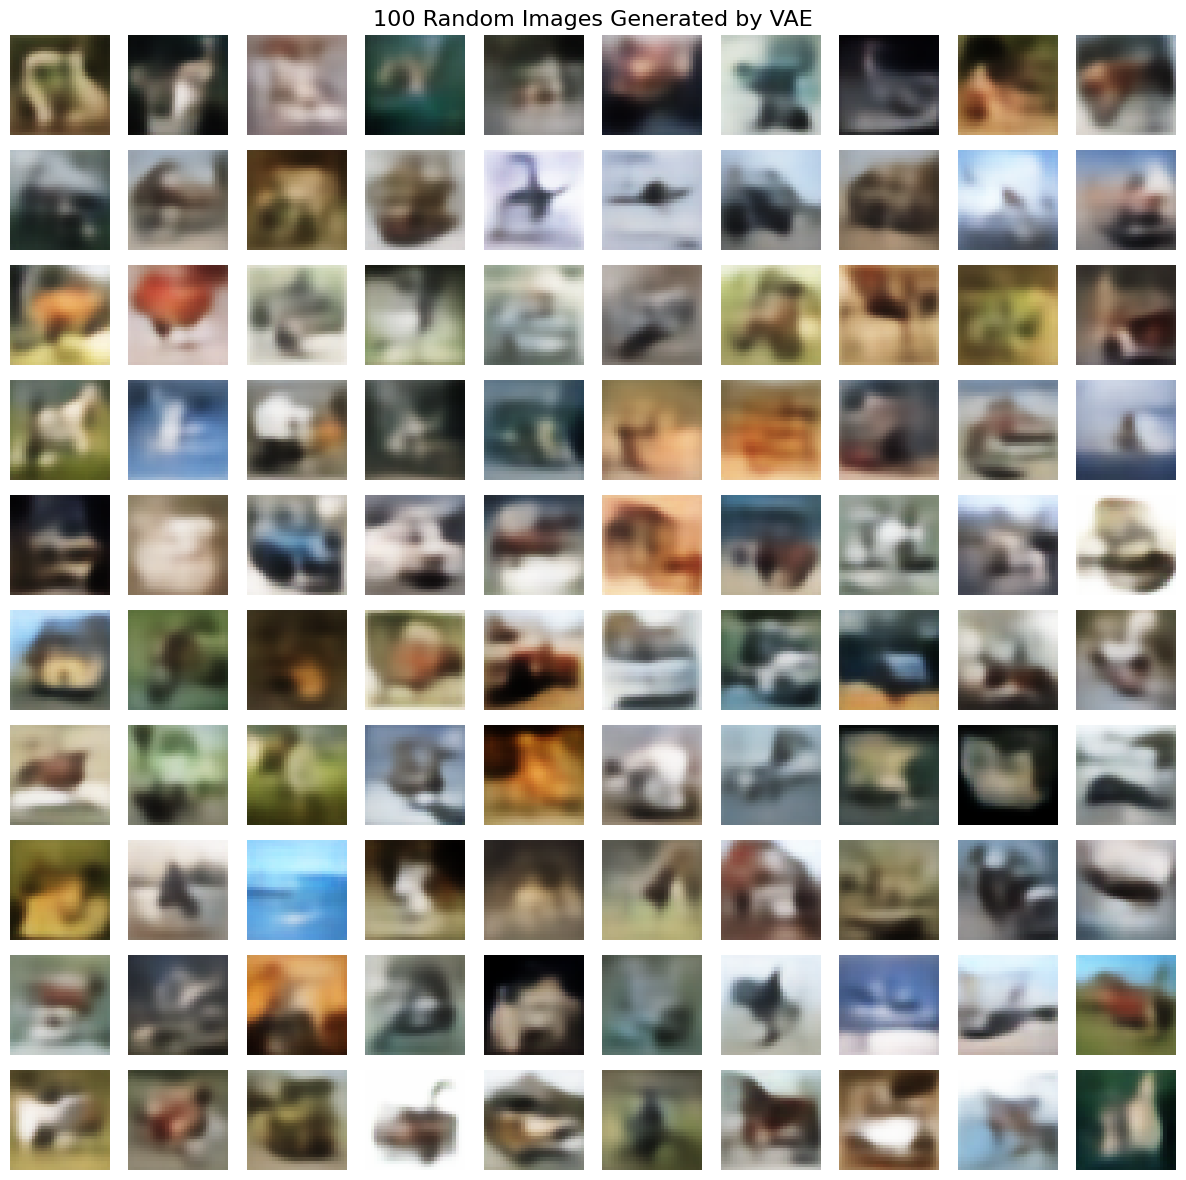


### Improved EMA DCGAN — 100 Randomly Generated Images

The improved DCGAN output below was produced from 100 random latent vectors using the EMA generator. The original `[-1, 1]` output was converted to `[0, 1]` only for display.

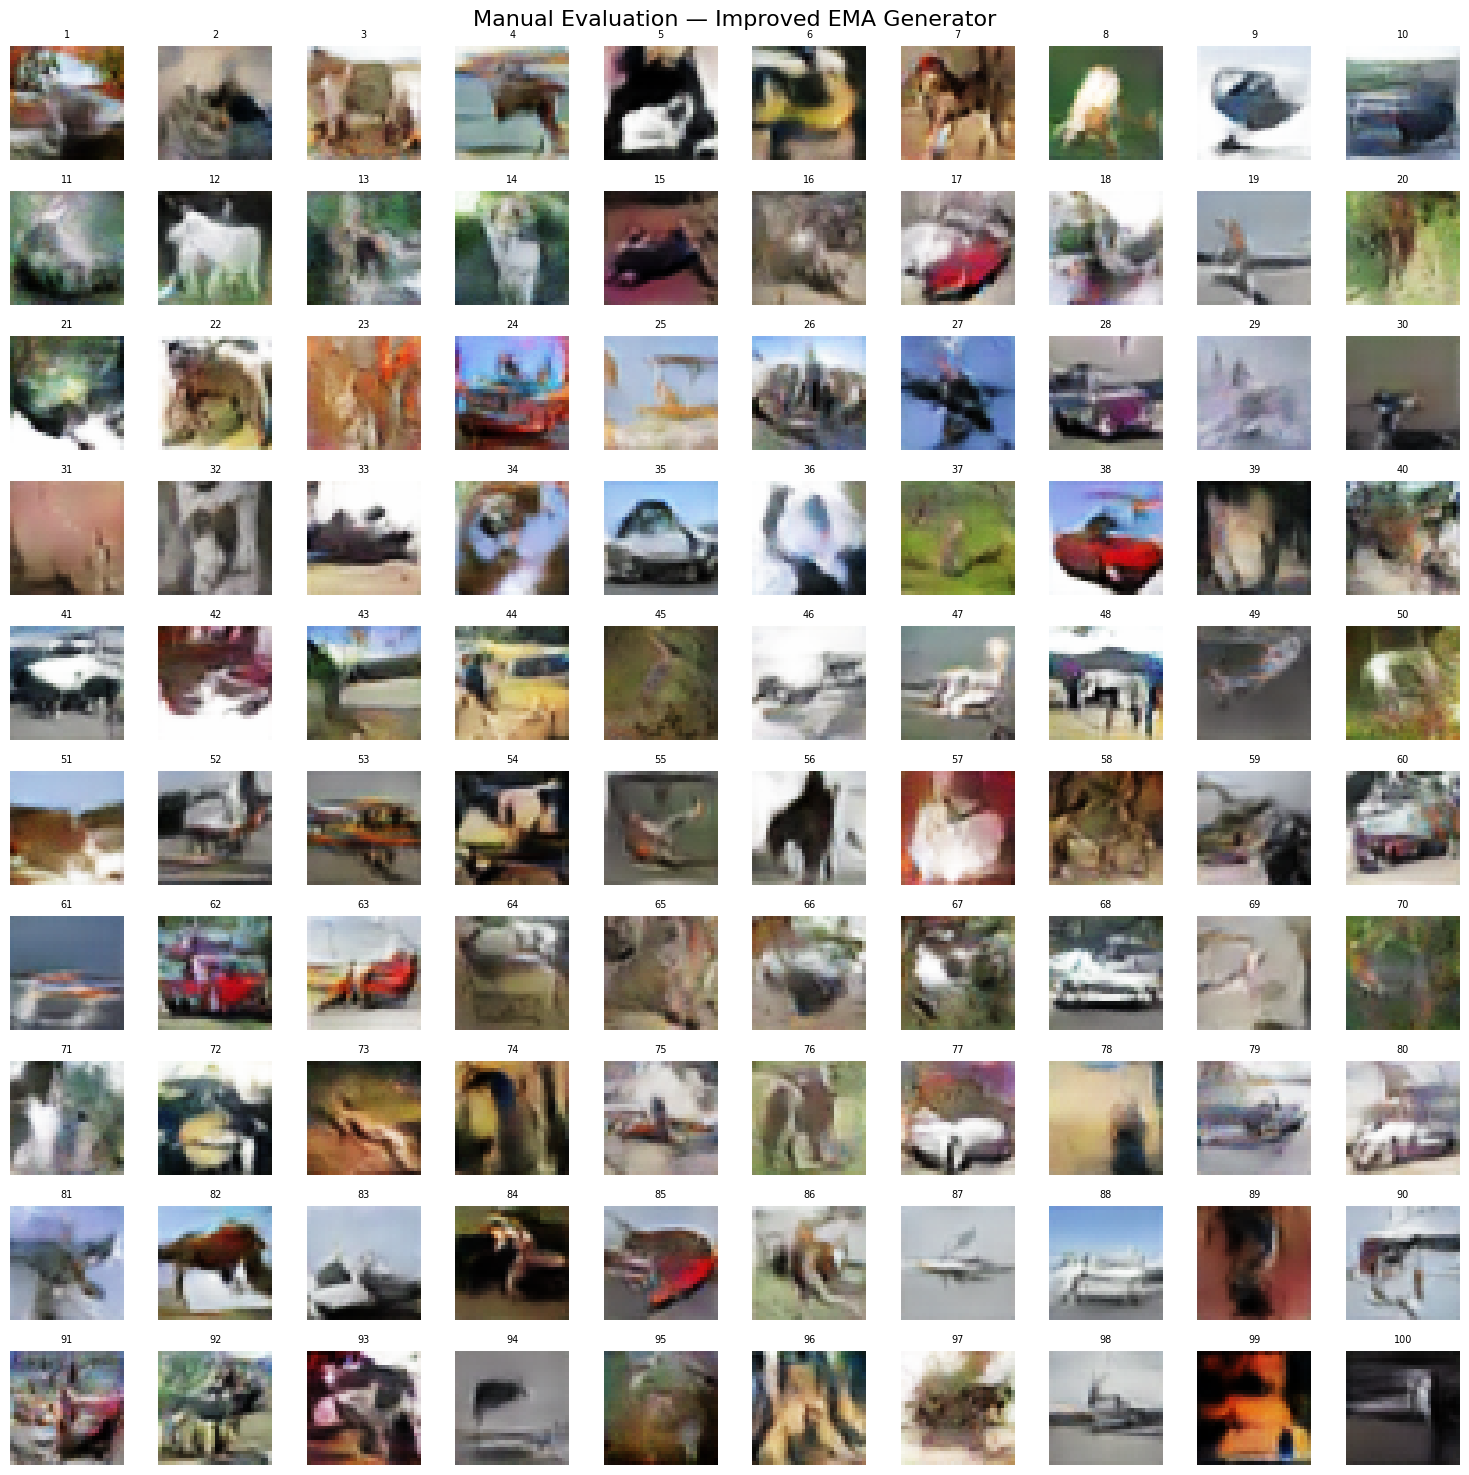


### Recorded comparison results

| Model | Clear | Marginal | Nonsense | Clear rate | Plausible acceptance | Supporting FID |
|---|---:|---:|---:|---:|---:|---:|
| Finalised VAE | 11 | 24 | 65 | 11% | 35% | Not available |
| Improved EMA DCGAN | 17 | 55 | 28 | 17% | 72% | 84.68 |

The detailed DCGAN review is used here because all 100 image indices were documented for the three categories. The DCGAN achieved a plausible acceptance rate **37 percentage points higher** than the VAE and reduced the nonsense rate from **65% to 28%**.


In [1]:
import pandas as pd

comparison_results = pd.DataFrame(
    {
        "Model": ["Finalised VAE", "Improved EMA DCGAN"],
        "Clear": [11, 17],
        "Marginal": [24, 55],
        "Nonsense": [65, 28],
        "Clear Rate (%)": [11.0, 17.0],
        "Plausible Acceptance (%)": [35.0, 72.0],
        "FID": [None, 84.68],
    }
)

comparison_results

,Model,Clear,Marginal,Nonsense,Clear Rate (%),Plausible Acceptance (%),FID
0,Finalised VAE,11,24,65,11.0,35.0,NaN
1,Improved EMA DCGAN,17,55,28,17.0,72.0,84.68


### Model selection

The **improved EMA DCGAN is selected** for final enhancement. Its generated sample contained substantially fewer nonsensical images and more plausible images than the finalised VAE under the shared manual rubric. The DCGAN's FID of 84.68 also confirms that it improved upon its own baseline, but it is not treated as a direct VAE-versus-GAN comparison because a matching VAE FID was unavailable.

This decision prioritises recognisability and plausibility while acknowledging that manual evaluation remains subjective. A blinded review using identical random seeds would provide a stronger future comparison.


## 2. Final DCGAN Enhancement with Augmentation

### Enhancement strategy

The selected improved DCGAN is restored from its saved generator, EMA-generator and discriminator weights. It is then fine-tuned for 10 additional epochs using horizontal-flip augmentation.

The augmentation is applied to both real and generated discriminator inputs, and to generated images during the generator update. It is used only during training; final outputs are generated directly by the EMA generator without augmentation or sharpening.

Smaller fine-tuning learning rates are used to reduce the risk of destroying the previously learned weights:

| Component | Fine-tuning learning rate |
|---|---:|
| Generator | 0.0001 |
| Discriminator | 0.00005 |

### Required local files

Place this notebook in the same folder as:

- `cifar-10-batches-py/`
- `improved_generator_final.weights.h5`
- `improved_ema_generator_final.weights.h5`
- `improved_discriminator_final.weights.h5`

The following cells restore and fine-tune the model; they do not rerun the original baseline or improved-model training.


### 2.1 Imports, dataset loading and preprocessing


In [2]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers


# ==================================================
# Configuration
# ==================================================

latent_dim = 100
batch_size = 128
dataset_path = Path("cifar-10-batches-py")


# ==================================================
# Load CIFAR-10
# ==================================================

def load_cifar_batch(file_path):
    with open(file_path, "rb") as file:
        batch = pickle.load(
            file,
            encoding="bytes"
        )

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    images = images.reshape(
        -1,
        3,
        32,
        32
    )

    images = images.transpose(
        0,
        2,
        3,
        1
    )

    return images, labels


x_train_batches = []
y_train_batches = []

for batch_number in range(1, 6):
    images, labels = load_cifar_batch(
        dataset_path
        / f"data_batch_{batch_number}"
    )

    x_train_batches.append(images)
    y_train_batches.append(labels)


x_train = np.concatenate(
    x_train_batches
)

y_train = np.concatenate(
    y_train_batches
)

x_test, y_test = load_cifar_batch(
    dataset_path / "test_batch"
)


# ==================================================
# Split and normalise
# ==================================================

y_train = y_train.astype(
    "int32"
).reshape(-1)

y_test = y_test.astype(
    "int32"
).reshape(-1)

(
    x_model_train,
    x_val,
    y_model_train,
    y_val
) = train_test_split(
    x_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

x_model_train_norm = (
    x_model_train.astype("float32")
    - 127.5
) / 127.5

x_val_norm = (
    x_val.astype("float32")
    - 127.5
) / 127.5

x_test_norm = (
    x_test.astype("float32")
    - 127.5
) / 127.5


# ==================================================
# Create training batches
# ==================================================

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        x_model_train_norm
    )
    .shuffle(
        buffer_size=10000
    )
    .batch(
        batch_size,
        drop_remainder=True
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

print(
    "Training images:",
    x_model_train_norm.shape
)

print(
    "Validation images:",
    x_val_norm.shape
)

print(
    "Training range:",
    x_model_train_norm.min(),
    "to",
    x_model_train_norm.max()
)

Training images: (45000, 32, 32, 3)
Validation images: (5000, 32, 32, 3)
Training range: -1.0 to 1.0


The same stratified 90:10 split and `[-1, 1]` normalisation used by the DCGAN are retained. This keeps the continuation consistent with the original model and its `tanh` output layer.


### 2.2 Restore the improved DCGAN


In [3]:
def build_generator():
    model = tf.keras.Sequential(
        name="generator"
    )

    model.add(
        layers.Dense(
            4 * 4 * 256,
            use_bias=False,
            input_shape=(latent_dim,)
        )
    )

    model.add(
        layers.BatchNormalization()
    )
    model.add(layers.ReLU())

    model.add(
        layers.Reshape(
            (4, 4, 256)
        )
    )

    # 4 × 4 → 8 × 8
    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(
        layers.BatchNormalization()
    )
    model.add(layers.ReLU())

    # 8 × 8 → 16 × 16
    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(
        layers.BatchNormalization()
    )
    model.add(layers.ReLU())

    # 16 × 16 → 32 × 32
    model.add(
        layers.Conv2DTranspose(
            3,
            kernel_size=4,
            strides=2,
            padding="same",
            activation="tanh"
        )
    )

    return model


def build_discriminator():
    return tf.keras.Sequential(
        [
            layers.Input(
                shape=(32, 32, 3)
            ),

            layers.Conv2D(
                64,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(
                alpha=0.2
            ),
            layers.Dropout(0.3),

            layers.Conv2D(
                128,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(
                alpha=0.2
            ),
            layers.Dropout(0.3),

            layers.Conv2D(
                256,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(
                alpha=0.2
            ),
            layers.Dropout(0.3),

            layers.Flatten(),
            layers.Dense(1)
        ],
        name="discriminator"
    )

In [4]:
weight_paths = {
    "generator": Path(
        "improved_generator_final.weights.h5"
    ),
    "ema_generator": Path(
        "improved_ema_generator_final.weights.h5"
    ),
    "discriminator": Path(
        "improved_discriminator_final.weights.h5"
    )
}

for model_name, path in weight_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {model_name}: {path}"
        )


final_generator = build_generator()
final_ema_generator = build_generator()
final_discriminator = build_discriminator()


final_generator.load_weights(
    weight_paths["generator"]
)

final_ema_generator.load_weights(
    weight_paths["ema_generator"]
)

final_discriminator.load_weights(
    weight_paths["discriminator"]
)


# Verify restored EMA generator
test_noise = tf.random.normal(
    shape=(16, latent_dim),
    seed=42
)

test_images = final_ema_generator(
    test_noise,
    training=False
)

print("All trained weights loaded.")
print("Generated shape:", test_images.shape)

print(
    "Generated range:",
    tf.reduce_min(test_images).numpy(),
    "to",
    tf.reduce_max(test_images).numpy()
)

All trained weights loaded.
Generated shape: (16, 32, 32, 3)
Generated range: -0.9985219 to 0.97049105


All three sets of saved weights are restored. The raw generator and discriminator continue training, while the EMA generator maintains a smoothed version of the generator weights for final image generation.


### 2.3 Mild horizontal-flip augmentation


In [5]:
class FastHorizontalFlip(layers.Layer):
    def call(
        self,
        images,
        training=False
    ):
        if training:
            return tf.image.random_flip_left_right(
                images
            )

        return images


gan_augmentation = FastHorizontalFlip()

In [6]:
sample_batch = next(
    iter(train_dataset)
)

augmented_batch = gan_augmentation(
    sample_batch,
    training=True
)

print(
    "Original shape:",
    sample_batch.shape
)

print(
    "Augmented shape:",
    augmented_batch.shape
)

print(
    "Augmented range:",
    tf.reduce_min(augmented_batch).numpy(),
    "to",
    tf.reduce_max(augmented_batch).numpy()
)

Original shape: (128, 32, 32, 3)
Augmented shape: (128, 32, 32, 3)
Augmented range: -1.0 to 1.0


Horizontal flipping is a mild spatial transformation that preserves the meaning of CIFAR-10 objects. More expensive translation augmentation was excluded because it caused inefficient random-operation loops in TensorFlow 2.10 and materially slowed training.


### 2.4 Augmentation-aware EMA training process


In [7]:
class AugmentedEMADCGAN(tf.keras.Model):
    def __init__(
        self,
        generator,
        discriminator,
        ema_generator,
        augmentation,
        latent_dim,
        real_label_value=0.9,
        ema_decay=0.999
    ):
        super().__init__()

        self.generator = generator
        self.discriminator = discriminator
        self.ema_generator = ema_generator
        self.augmentation = augmentation

        self.latent_dim = latent_dim
        self.real_label_value = real_label_value
        self.ema_decay = ema_decay

        # EMA generator is updated manually
        self.ema_generator.trainable = False

    def compile(
        self,
        generator_optimizer,
        discriminator_optimizer,
        loss_function,
        **kwargs
    ):
        super().compile(**kwargs)

        self.generator_optimizer = (
            generator_optimizer
        )

        self.discriminator_optimizer = (
            discriminator_optimizer
        )

        self.loss_function = loss_function

        self.generator_loss_tracker = (
            tf.keras.metrics.Mean(
                name="generator_loss"
            )
        )

        self.discriminator_loss_tracker = (
            tf.keras.metrics.Mean(
                name="discriminator_loss"
            )
        )

    @property
    def metrics(self):
        return [
            self.generator_loss_tracker,
            self.discriminator_loss_tracker
        ]

    def train_step(self, real_images):

        if isinstance(
            real_images,
            (tuple, list)
        ):
            real_images = real_images[0]

        current_batch_size = tf.shape(
            real_images
        )[0]

        # ==========================================
        # 1. Train discriminator
        # ==========================================

        random_noise = tf.random.normal(
            shape=(
                current_batch_size,
                self.latent_dim
            )
        )

        generated_images = self.generator(
            random_noise,
            training=True
        )

        generated_images = tf.stop_gradient(
            generated_images
        )

        with tf.GradientTape() as discriminator_tape:

            augmented_real_images = (
                self.augmentation(
                    real_images,
                    training=True
                )
            )

            augmented_fake_images = (
                self.augmentation(
                    generated_images,
                    training=True
                )
            )

            real_predictions = self.discriminator(
                augmented_real_images,
                training=True
            )

            fake_predictions = self.discriminator(
                augmented_fake_images,
                training=True
            )

            real_labels = (
                tf.ones_like(real_predictions)
                * self.real_label_value
            )

            fake_labels = tf.zeros_like(
                fake_predictions
            )

            real_loss = self.loss_function(
                real_labels,
                real_predictions
            )

            fake_loss = self.loss_function(
                fake_labels,
                fake_predictions
            )

            discriminator_loss = (
                real_loss + fake_loss
            ) / 2.0

        discriminator_gradients = (
            discriminator_tape.gradient(
                discriminator_loss,
                self.discriminator.trainable_variables
            )
        )

        self.discriminator_optimizer.apply_gradients(
            zip(
                discriminator_gradients,
                self.discriminator.trainable_variables
            )
        )

        # ==========================================
        # 2. Train generator
        # ==========================================

        random_noise = tf.random.normal(
            shape=(
                current_batch_size,
                self.latent_dim
            )
        )

        with tf.GradientTape() as generator_tape:

            generated_images = self.generator(
                random_noise,
                training=True
            )

            augmented_generated_images = (
                self.augmentation(
                    generated_images,
                    training=True
                )
            )

            fake_predictions = self.discriminator(
                augmented_generated_images,
                training=False
            )

            generator_loss = self.loss_function(
                tf.ones_like(fake_predictions),
                fake_predictions
            )

        generator_gradients = (
            generator_tape.gradient(
                generator_loss,
                self.generator.trainable_variables
            )
        )

        self.generator_optimizer.apply_gradients(
            zip(
                generator_gradients,
                self.generator.trainable_variables
            )
        )

        # ==========================================
        # 3. Update EMA generator
        # ==========================================

        for ema_weight, generator_weight in zip(
            self.ema_generator.weights,
            self.generator.weights
        ):
            ema_weight.assign(
                self.ema_decay * ema_weight
                + (1.0 - self.ema_decay)
                * generator_weight
            )

        # Record epoch losses
        self.generator_loss_tracker.update_state(
            generator_loss
        )

        self.discriminator_loss_tracker.update_state(
            discriminator_loss
        )

        return {
            "generator_loss":
                self.generator_loss_tracker.result(),

            "discriminator_loss":
                self.discriminator_loss_tracker.result()
        }

The training step alternates between discriminator and generator updates. One-sided label smoothing remains at 0.9, and the EMA generator is updated after every generator step using a decay of 0.999.


### 2.5 Compile and fine-tune


In [8]:
final_gan = AugmentedEMADCGAN(
    generator=final_generator,
    discriminator=final_discriminator,
    ema_generator=final_ema_generator,
    augmentation=gan_augmentation,
    latent_dim=latent_dim,
    real_label_value=0.9,
    ema_decay=0.999
)

final_gan.compile(
    generator_optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001,
        beta_1=0.5
    ),

    discriminator_optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00005,
        beta_1=0.5
    ),

    loss_function=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    ),

    steps_per_execution=10
)

print(
    "Generator learning rate:",
    final_gan.generator_optimizer.learning_rate.numpy()
)

print(
    "Discriminator learning rate:",
    final_gan.discriminator_optimizer.learning_rate.numpy()
)

print("Final augmented GAN compiled.")

Generator learning rate: 1e-04
Discriminator learning rate: 5e-05
Final augmented GAN compiled.


In [9]:
final_history = final_gan.fit(
    train_dataset,
    epochs=10,
    verbose=2
)

Epoch 1/10
351/351 - 26s - generator_loss: 0.8767 - discriminator_loss: 0.6783 - 26s/epoch - 74ms/step
Epoch 2/10
351/351 - 20s - generator_loss: 0.8764 - discriminator_loss: 0.6790 - 20s/epoch - 58ms/step
Epoch 3/10
351/351 - 20s - generator_loss: 0.8759 - discriminator_loss: 0.6795 - 20s/epoch - 57ms/step
Epoch 4/10
351/351 - 20s - generator_loss: 0.8750 - discriminator_loss: 0.6797 - 20s/epoch - 56ms/step
Epoch 5/10
351/351 - 20s - generator_loss: 0.8739 - discriminator_loss: 0.6797 - 20s/epoch - 56ms/step
Epoch 6/10
351/351 - 20s - generator_loss: 0.8750 - discriminator_loss: 0.6799 - 20s/epoch - 56ms/step
Epoch 7/10
351/351 - 20s - generator_loss: 0.8753 - discriminator_loss: 0.6802 - 20s/epoch - 57ms/step
Epoch 8/10
351/351 - 20s - generator_loss: 0.8734 - discriminator_loss: 0.6805 - 20s/epoch - 56ms/step
Epoch 9/10
351/351 - 20s - generator_loss: 0.8741 - discriminator_loss: 0.6806 - 20s/epoch - 56ms/step
Epoch 10/10
351/351 - 20s - generator_loss: 0.8755 - discriminator_loss: 

The losses remained stable during fine-tuning: generator loss changed from approximately 0.8773 to 0.8720, while discriminator loss remained around 0.68. GAN losses do not directly measure image quality, but the stable values show that the short continuation did not create an obvious training collapse.


### 2.6 Save the final augmented model


In [10]:
final_gan.generator.save_weights(
    "final_augmented_generator.weights.h5"
)

final_gan.ema_generator.save_weights(
    "final_augmented_ema_generator.weights.h5"
)

final_gan.discriminator.save_weights(
    "final_augmented_discriminator.weights.h5"
)

print("Final augmented-model weights saved.")

Final augmented-model weights saved.


In [11]:
np.savez(
    "final_augmented_history.npz",
    generator_loss=(
        final_history.history[
            "generator_loss"
        ]
    ),
    discriminator_loss=(
        final_history.history[
            "discriminator_loss"
        ]
    )
)

print("Fine-tuning history saved.")

Fine-tuning history saved.


The EMA weights in `final_augmented_ema_generator.weights.h5` are used as the final generative model. The raw generator and discriminator are also saved so that training can be resumed if required.


### 2.7 Fixed-noise comparison before and after augmentation


In [12]:
original_ema_generator = build_generator()

original_ema_generator.load_weights(
    "improved_ema_generator_final.weights.h5"
)

print("Original EMA generator loaded.")

Original EMA generator loaded.


In [13]:
comparison_noise = tf.random.normal(
    shape=(16, latent_dim),
    seed=42
)

original_images = original_ema_generator(
    comparison_noise,
    training=False
)

augmented_images = final_gan.ema_generator(
    comparison_noise,
    training=False
)

# Convert [-1, 1] to [0, 1]
original_images = tf.clip_by_value(
    (original_images + 1.0) / 2.0,
    0.0,
    1.0
)

augmented_images = tf.clip_by_value(
    (augmented_images + 1.0) / 2.0,
    0.0,
    1.0
)

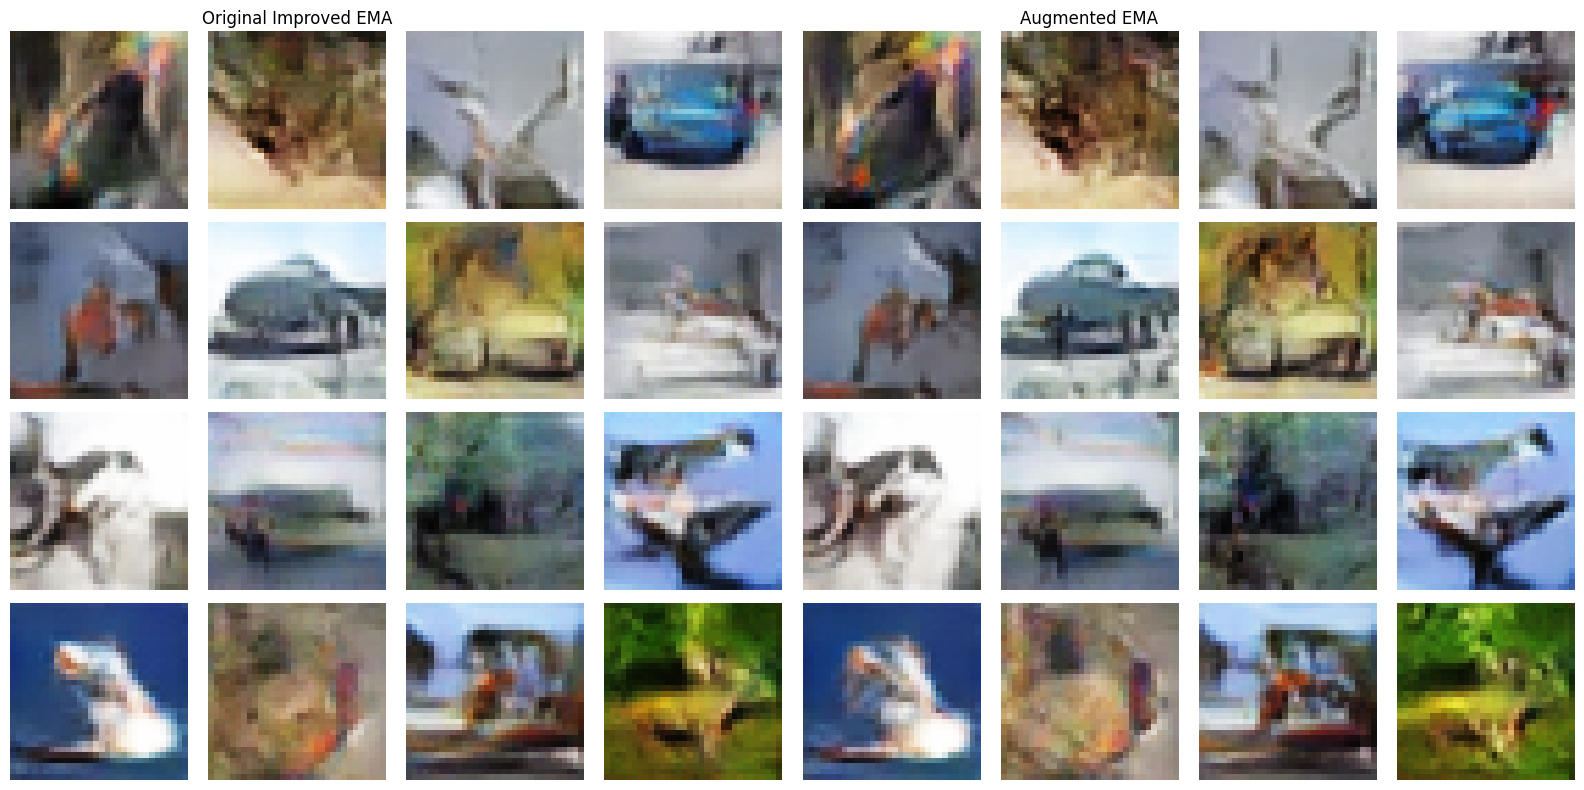

In [14]:
fig, axes = plt.subplots(
    4,
    8,
    figsize=(16, 8)
)

for row in range(4):
    for column in range(4):
        index = row * 4 + column

        axes[row, column].imshow(
            original_images[index]
        )

        axes[row, column + 4].imshow(
            augmented_images[index]
        )

        axes[row, column].axis("off")
        axes[row, column + 4].axis("off")

axes[0, 1].set_title(
    "Original Improved EMA",
    fontsize=12
)

axes[0, 5].set_title(
    "Augmented EMA",
    fontsize=12
)

plt.tight_layout()
plt.show()

The same 16 latent vectors are supplied to both EMA generators. This isolates the effect of fine-tuning from differences caused by random inputs. Visual inspection showed clearer shapes in the augmented EMA outputs while retaining variation across samples.


## 3. Final Conclusion

The improved EMA DCGAN was selected over the finalised VAE because its manually assessed plausible acceptance rate was **72%**, compared with **35%** for the VAE, and its nonsense rate was substantially lower. The VAE FID calculation was unavailable because of a GPU memory error, so the cross-model decision was based on the common 100-image manual protocol rather than an incomplete FID comparison.

The selected DCGAN was subsequently fine-tuned for 10 epochs using mild horizontal-flip augmentation, smaller learning rates, one-sided label smoothing and EMA weight updates. Fixed-noise visual comparison indicated that the final augmented EMA generator produced clearer images without obvious training instability.

### Final selected artifact

`final_augmented_ema_generator.weights.h5`

### Limitations

- CIFAR-10 images are only 32 × 32 pixels, limiting fine visual detail.
- Manual categorisation is subjective and was not conducted as a blinded study.
- The post-augmentation model was selected through fixed-noise visual inspection; a new FID or blinded 100-image review would strengthen the final quantitative evidence.
